In [1]:
from __future__ import annotations

import argparse
import contextlib
import os
from pathlib import Path

os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")

import jax
import matplotlib.pyplot as plt
import MDAnalysis as mda
import numpy as np
from MDAnalysis.analysis import align
from dadapy import DiffImbalance
from sklearn.decomposition import PCA

os.environ["CUDA_VISIBLE_DEVICES"] = '0' 
jax.config.update("jax_platform_name", "gpu")  # can run on 'cpu' or 'gpu'; restart the
                                               # notebook kernel to make this change effective

%matplotlib inline
%load_ext autoreload
%autoreload 2

/media/users/debarshi/scratch/mambaforge/envs/md/lib/python3.11/site-packages/Bio/Application/__init__.py:40: BiopythonDeprecationWarning: The Bio.Application modules and modules relying on it have been deprecated.

Due to the on going maintenance burden of keeping command line application
wrappers up to date, we have decided to deprecate and eventually remove these
modules.

We instead now recommend building your command line and invoking it directly
with the subprocess module.
  warnings.warn(


In [2]:
def ensure_aligned_s1_trajectory(
    traj_path: Path,
    first_frame_path: Path,
    aligned_traj_path: Path,
    overwrite: bool = False,
) -> None:
    if aligned_traj_path.exists() and not overwrite:
        print(f"Reusing aligned trajectory: {aligned_traj_path}")
        return

    print(f"Building aligned trajectory from: {traj_path}")
    uni_og_s1 = mda.Universe(str(traj_path))
    uni_og_s1.trajectory[0]

    with mda.Writer(str(first_frame_path), uni_og_s1.atoms.n_atoms) as writer:
        writer.write(uni_og_s1.atoms)

    first_frame_uni_s1 = mda.Universe(str(first_frame_path))

    aligned_traj_s1 = align.AlignTraj(
        mobile=uni_og_s1,
        reference=first_frame_uni_s1,
        select="all",
        strict=True,
        verbose=True,
        prefix=str(aligned_traj_path.parent / "rmsfit_"),
    )
    aligned_traj_s1.run()

    if not aligned_traj_path.exists():
        raise FileNotFoundError(
            f"Expected aligned trajectory at {aligned_traj_path}, but it was not created."
        )


def load_flattened_positions(aligned_traj_path: Path) -> tuple[np.ndarray, int, int]:
    uni_s1 = mda.Universe(str(aligned_traj_path))
    traj_s1 = uni_s1.trajectory.trajectory

    n_atoms = traj_s1.n_atoms
    n_frames = traj_s1.n_frames

    atom_pos_s1 = np.zeros((n_frames, 3 * n_atoms), dtype=float)

    for i, frame in enumerate(traj_s1):
        atom_pos_s1[i, :] = frame.positions.flatten()

    return atom_pos_s1, n_atoms, n_frames

In [3]:
def compute_pca_scores(
    atom_positions: np.ndarray,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    pca_s1 = PCA()
    reduced_coords_s1 = pca_s1.fit_transform(atom_positions)
    eigvals_s1 = pca_s1.explained_variance_
    expl_var_s1 = pca_s1.explained_variance_ratio_
    return reduced_coords_s1, eigvals_s1, expl_var_s1


def build_top_pc_dataset(
    reduced_coords_s1: np.ndarray,
    dE_s1: np.ndarray,
    n_pcs: int,
    frame_start: int,
    frame_stride: int,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, list[str], np.ndarray]:
    if reduced_coords_s1.shape[0] != dE_s1.shape[0]:
        raise ValueError(
            "PCA frame count and dE frame count differ: "
            f"{reduced_coords_s1.shape[0]} vs {dE_s1.shape[0]}"
        )

    if n_pcs < 1 or n_pcs > reduced_coords_s1.shape[1]:
        raise ValueError(
            f"Requested n_pcs={n_pcs}, but PCA produced {reduced_coords_s1.shape[1]} components."
        )

    frame_idx = np.arange(frame_start, reduced_coords_s1.shape[0], frame_stride)
    data_A = reduced_coords_s1[frame_idx, :n_pcs].copy()
    y = dE_s1[frame_idx]
    data_B = y[:, np.newaxis]
    feature_names = [f"PC_{i+1}" for i in range(n_pcs)]
    periods_A = np.zeros(n_pcs, dtype=float)

    return data_A, data_B, frame_idx, feature_names, periods_A


def train_dii(
    data_A: np.ndarray,
    data_B: np.ndarray,
    periods_A,
    seed: int,
    num_epochs: int,
    learning_rate_decay: str | None,
) -> tuple[DiffImbalance, np.ndarray, np.ndarray, float]:
    dii = DiffImbalance(
        data_A=data_A,
        data_B=data_B,
        periods_A=periods_A,
        periods_B=None,
        seed=seed,
        num_epochs=num_epochs,
        batches_per_epoch=1,
        l1_strength=0.0,
        point_adapt_lambda=True,
        k_init=60,
        k_final=60,
        lambda_factor=0.1,
        params_init=None,
        optimizer_name="adam",
        learning_rate=1e-2,
        learning_rate_decay=learning_rate_decay,
        num_points_rows=None,
    )
    weights, imbs = dii.train()
    imb_final, _ = dii.return_final_dii(
        compute_error=False, ratio_rows_columns=None, seed=0, discard_close_ind=0
    )
    return dii, weights, imbs, float(imb_final)

In [4]:
base_dir = Path("./")
traj_dir = base_dir / "traj_data"
computed_dir = base_dir / "computed_data"
pca_dir = base_dir / "PCA_projections"

traj_path = traj_dir / "traj_S1.xyz"
first_frame_path = traj_dir / "first_frame_s1.xyz"
aligned_traj_path = traj_dir / "rmsfit_traj_S1.xyz"
pc_dump_path = computed_dir / "9_top10_pcs_s1.npz"

pca_dir.mkdir(parents=True, exist_ok=True)
computed_dir.mkdir(parents=True, exist_ok=True)

In [5]:
n_pcs = 10
frame_start = 1
frame_stride = 20
seed_val = 37

In [6]:
ensure_aligned_s1_trajectory(
    traj_path=traj_path,
    first_frame_path=first_frame_path,
    aligned_traj_path=aligned_traj_path,
    overwrite=False,  # Recompute the aligned trajectory even if the aligned file already exists
)

atom_pos_s1, n_atoms, n_frames = load_flattened_positions(aligned_traj_path)
print(f"Aligned S1 flattened coordinates shape: {atom_pos_s1.shape}")
print(f"n_atoms={n_atoms}, n_frames={n_frames}")

reduced_coords_s1, eigvals_s1, expl_var_s1 = compute_pca_scores(atom_pos_s1)
print(f"PCA score matrix shape: {reduced_coords_s1.shape}")
print(f"Top {n_pcs} explained variance ratios: {expl_var_s1[:n_pcs]}")
print(
    f"Top {n_pcs} cumulative explained variance: "
    f"{np.cumsum(expl_var_s1[:n_pcs])[-1]:.6f}"
)

Reusing aligned trajectory: traj_data/rmsfit_traj_S1.xyz
Aligned S1 flattened coordinates shape: (234664, 141)
n_atoms=47, n_frames=234664
PCA score matrix shape: (234664, 141)
Top 10 explained variance ratios: [0.77 0.14 0.03 0.02 0.01 0.01 0.   0.   0.   0.  ]
Top 10 cumulative explained variance: 0.989084


# fosc

In [7]:
base_dir = Path("../Molecular-Motors_tdfluorescence")
traj_dir = base_dir / "traj_data"
computed_dir = base_dir / "computed_data"
pca_dir = base_dir / "PCA_projections"

traj_path = traj_dir / "tdtraj.xyz"
first_frame_path = traj_dir / "first_frame_tdtraj.xyz"
aligned_traj_path = traj_dir / "rmsfit_tdtraj.xyz"
pc_dump_path = computed_dir / "9_top10_pcs_s1.npz"

pca_dir.mkdir(parents=True, exist_ok=True)
computed_dir.mkdir(parents=True, exist_ok=True)

In [8]:
n_pcs = 10
frame_start = 1
frame_stride = 20
seed_val = 37

In [9]:
ensure_aligned_s1_trajectory(
    traj_path=traj_path,
    first_frame_path=first_frame_path,
    aligned_traj_path=aligned_traj_path,
    overwrite=False,  # Recompute the aligned trajectory even if the aligned file already exists
)

atom_pos_s1, n_atoms, n_frames = load_flattened_positions(aligned_traj_path)
print(f"Aligned S1 flattened coordinates shape: {atom_pos_s1.shape}")
print(f"n_atoms={n_atoms}, n_frames={n_frames}")

reduced_coords_s1, eigvals_s1, expl_var_s1 = compute_pca_scores(atom_pos_s1)
print(f"PCA score matrix shape: {reduced_coords_s1.shape}")
print(f"Top {n_pcs} explained variance ratios: {expl_var_s1[:n_pcs]}")
print(
    f"Top {n_pcs} cumulative explained variance: "
    f"{np.cumsum(expl_var_s1[:n_pcs])[-1]:.6f}"
)

Reusing aligned trajectory: ../Molecular-Motors_tdfluorescence/traj_data/rmsfit_tdtraj.xyz
Aligned S1 flattened coordinates shape: (206736, 141)
n_atoms=47, n_frames=206736
PCA score matrix shape: (206736, 141)
Top 10 explained variance ratios: [0.77 0.13 0.03 0.02 0.01 0.01 0.   0.   0.   0.  ]
Top 10 cumulative explained variance: 0.985646


In [13]:
tdener_path = Path("../Molecular-Motors_tdfluorescence/traj_data/tdener.dat")
tdener = np.loadtxt(tdener_path)
tdm_mask = tdener != 0.0

print(reduced_coords_s1.shape, tdm_mask.shape)
if reduced_coords_s1.shape[0] != tdm_mask.shape[0]:
    raise ValueError(
        f"PCA frame count and tdener frame count differ: "
        f"{reduced_coords_s1.shape[0]} vs {tdm_mask.shape[0]}"
    )

# Keep only the PC-score rows corresponding to the frames retained by the TDM filter
reduced_coords_tdm = reduced_coords_s1[tdm_mask]

fosc_s1_path = Path("../Molecular-Motors_tdfluorescence/traj_data/tdfosc_tdm.dat")
fosc_s1 = np.loadtxt(fosc_s1_path)

if reduced_coords_tdm.shape[0] != fosc_s1.shape[0]:
    raise ValueError(
        f"Filtered PCA row count and tdfosc_tdm length differ: "
        f"{reduced_coords_tdm.shape[0]} vs {fosc_s1.shape[0]}"
    )

data_A, data_B, frame_idx, feature_names, periods_A = build_top_pc_dataset(
    reduced_coords_s1=reduced_coords_tdm,
    dE_s1=fosc_s1,
    n_pcs=n_pcs,
    frame_start=frame_start,
    frame_stride=frame_stride,
)

# Optional but useful: original tdtraj frame numbers that each sampled row came from
selected_original_frame_idx = np.flatnonzero(tdm_mask)[frame_idx]

print(f"TDM-kept PCA score matrix shape: {reduced_coords_tdm.shape}")
print(f"Selected filtered-row indices shape: {frame_idx.shape}")
print(f"Selected original tdtraj frame indices shape: {selected_original_frame_idx.shape}")
print(f"data_A shape (top-PC scores): {data_A.shape}")
print(f"data_B shape (fosc target): {data_B.shape}")
print("Feature names:", feature_names)
print("First 20 original tdtraj frame indices:", selected_original_frame_idx[:20])
print("data_A min by PC:", data_A.min(axis=0))
print("data_A max by PC:", data_A.max(axis=0))

(206736, 141) (206736,)
TDM-kept PCA score matrix shape: (206670, 141)
Selected filtered-row indices shape: (10334,)
Selected original tdtraj frame indices shape: (10334,)
data_A shape (top-PC scores): (10334, 10)
data_B shape (fosc target): (10334, 1)
Feature names: ['PC_1', 'PC_2', 'PC_3', 'PC_4', 'PC_5', 'PC_6', 'PC_7', 'PC_8', 'PC_9', 'PC_10']
First 20 original tdtraj frame indices: [  1  21  41  61  81 101 121 141 161 181 201 221 241 261 281 301 321 341
 361 381]
data_A min by PC: [-4.28 -4.79 -3.05 -1.57 -1.45 -1.09 -0.83 -1.   -0.88 -0.59]
data_A max by PC: [8.53 2.8  1.95 1.7  1.48 1.37 1.09 1.61 0.54 0.82]


Training:   0%|          | 0/200 [00:00<?, ?it/s]

Optimal DII over full data set after 500 epochs: 0.732856
Final weights after 500 epochs: [3.01e-01 3.76e-02 1.28e-02 1.64e-02 2.41e-06 8.76e-08 1.41e-06 6.52e-06
 8.74e-02 1.42e-08]
Weights > 0.1: [0.3]
Indices with weights > 0.1 (1-based): [1]


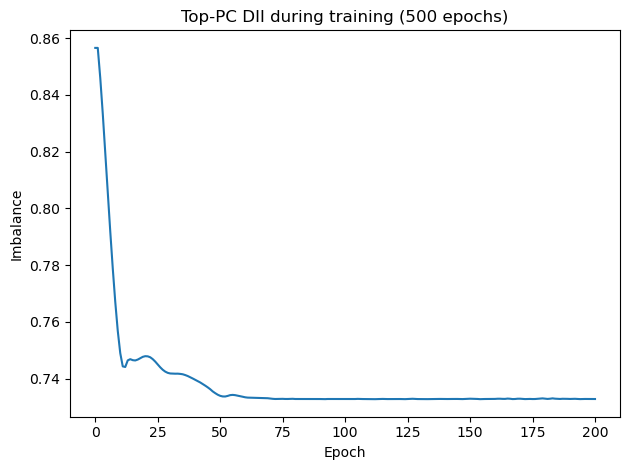

In [14]:
np.random.seed(seed_val)

dii, weights, imbs, imb_final = train_dii(
    data_A=data_A,
    data_B=data_B,
    periods_A=None,
    seed=seed_val,
    num_epochs=200,
    learning_rate_decay=None,
)

plt.figure()
plt.plot(imbs)
plt.xlabel("Epoch")
plt.ylabel("Imbalance")
plt.title("Top-PC DII during training (500 epochs)")
plt.tight_layout()

print(f"Optimal DII over full data set after 500 epochs: {imb_final:.6f}")
final_weights = weights[-1]
print("Final weights after 500 epochs:", final_weights)
print("Weights > 0.1:", final_weights[final_weights > 0.1])
print(
    "Indices with weights > 0.1 (1-based):",
    np.argwhere(final_weights > 0.1).ravel() + 1,
)

Training:   0%|          | 0/100 [00:00<?, ?it/s]

Optimal DII over full data set after 500 epochs: 0.733107
Final weights after 500 epochs: [2.91e-01 4.77e-02 9.60e-03 1.59e-02 5.20e-05 1.68e-03 9.74e-05 7.30e-04
 1.12e-01 7.84e-04]
Weights > 0.1: [0.29 0.11]
Indices with weights > 0.1 (1-based): [1 9]


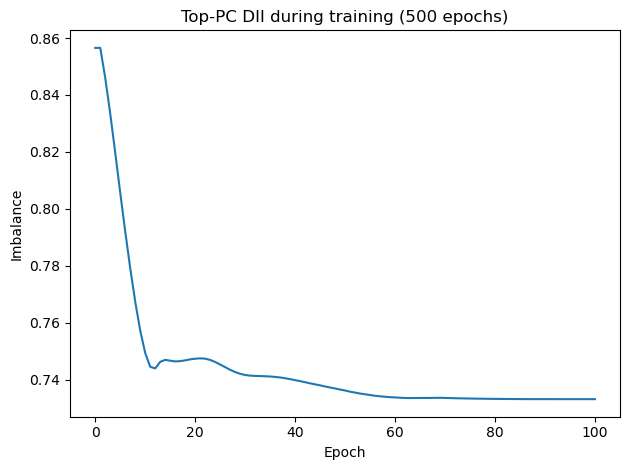

In [16]:
np.random.seed(seed_val)

dii, weights, imbs, imb_final = train_dii(
    data_A=data_A,
    data_B=data_B,
    periods_A=None,
    seed=seed_val,
    num_epochs=100,
    learning_rate_decay="cos",
)

plt.figure()
plt.plot(imbs)
plt.xlabel("Epoch")
plt.ylabel("Imbalance")
plt.title("Top-PC DII during training (500 epochs)")
plt.tight_layout()

print(f"Optimal DII over full data set after 500 epochs: {imb_final:.6f}")
final_weights = weights[-1]
print("Final weights after 500 epochs:", final_weights)
print("Weights > 0.1:", final_weights[final_weights > 0.1])
print(
    "Indices with weights > 0.1 (1-based):",
    np.argwhere(final_weights > 0.1).ravel() + 1,
)

In [17]:
# forward greedy search
with open("9_fosc-tdm.out", "w") as f:
    with contextlib.redirect_stdout(f), contextlib.redirect_stderr(f):
        (
            feature_sets_fw_fosc,
            diis_fw_fosc,
            errors_fw_fosc,
            weights_fw_fosc,
        ) = dii.forward_greedy_feature_selection(
            n_features_max=n_pcs,
            n_best=2,
            compute_error=True,
            ratio_rows_columns=1,
            seed=seed_val,
            discard_close_ind=0,
        )

Training:   0%|          | 0/100 [00:00<?, ?it/s]

Training:   0%|          | 0/100 [00:00<?, ?it/s]

Training:   0%|          | 0/100 [00:00<?, ?it/s]

Training:   0%|          | 0/100 [00:00<?, ?it/s]

Training:   0%|          | 0/100 [00:00<?, ?it/s]

...

Training:   0%|          | 0/100 [00:00<?, ?it/s]

Training:   0%|          | 0/100 [00:00<?, ?it/s]

Training:   0%|          | 0/100 [00:00<?, ?it/s]

Training:   0%|          | 0/100 [00:00<?, ?it/s]

Training:   0%|          | 0/100 [00:00<?, ?it/s]

In [18]:
print(f"\nSelected feature subsets:\n {feature_sets_fw_fosc}\n")
print("Forward DIIs:", diis_fw_fosc)
print("Forward Errors:", errors_fw_fosc)
print("Forward Weights:", weights_fw_fosc)


Selected feature subsets:
 [[0], [0, 1], [0, 1, 8], [0, 1, 3, 8], [0, 1, 3, 4, 8], [0, 1, 3, 4, 8, 9], [0, 1, 3, 4, 6, 8, 9], [0, 1, 3, 4, 6, 7, 8, 9], [0, 1, 2, 3, 4, 5, 6, 8, 9], [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]]

Forward DIIs: [0.8246455192565918, 0.7485082745552063, 0.7384219765663147, 0.7358114719390869, 0.7358192801475525, 0.7358354330062866, 0.7357637882232666, 0.7356988787651062, 0.7358068823814392, 0.7358440160751343]
Forward Errors: [0.003481165738776326, 0.003924734890460968, 0.003998764790594578, 0.0040843733586370945, 0.0040839845314621925, 0.004083296749740839, 0.004087402019649744, 0.004093652591109276, 0.004106396343559027, 0.004114880226552486]
Forward Weights: [array([0.1, 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ]), array([0.14, 0.03, 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
      dtype=float32), array([0.17, 0.02, 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.05, 0.  ],
      dtype=float32), array([0.19, 0.03, 0.  , 0.01, 0.  , 0.  , 0.  , 0.  , 0.06, 0.  ],
      

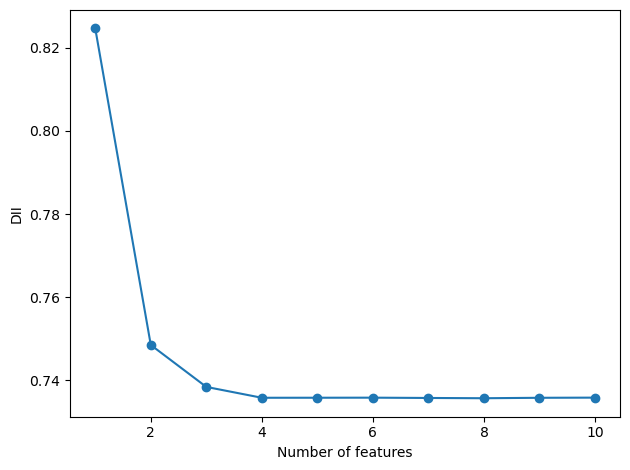

In [19]:
plt.figure()
plt.xlabel("Number of features")
plt.ylabel("DII")
plt.plot(range(1, len(feature_sets_fw_fosc) + 1), diis_fw_fosc, "o-")
plt.tight_layout()

In [20]:
print("\nGreedy subsets with PC names:\n")
for subset in feature_sets_fw_fosc:
    print([feature_names[i] for i in subset])


Greedy subsets with PC names:

['PC_1']
['PC_1', 'PC_2']
['PC_1', 'PC_2', 'PC_9']
['PC_1', 'PC_2', 'PC_4', 'PC_9']
['PC_1', 'PC_2', 'PC_4', 'PC_5', 'PC_9']
['PC_1', 'PC_2', 'PC_4', 'PC_5', 'PC_9', 'PC_10']
['PC_1', 'PC_2', 'PC_4', 'PC_5', 'PC_7', 'PC_9', 'PC_10']
['PC_1', 'PC_2', 'PC_4', 'PC_5', 'PC_7', 'PC_8', 'PC_9', 'PC_10']
['PC_1', 'PC_2', 'PC_3', 'PC_4', 'PC_5', 'PC_6', 'PC_7', 'PC_9', 'PC_10']
['PC_1', 'PC_2', 'PC_3', 'PC_4', 'PC_5', 'PC_6', 'PC_7', 'PC_8', 'PC_9', 'PC_10']
